# Preprocessing

In [2]:
import pandas as pd
import seaborn as sns

In [3]:
user_features= pd.read_csv('user_features_data/user_features.csv')

In [4]:
user_features.columns

Index(['user_id', 'birthdate', 'gender', 'married', 'has_children',
       'home_country', 'home_city', 'home_airport', 'home_airport_lat',
       'home_airport_lon', 'sign_up_date', 'Age', 'days_in', 'Age Group',
       'trip_session_ratio', 'no_cancellations', 'sum_page_clicks',
       'ave_page_clicks', 'ave_discount', 'nights_median', 'hotel_tot_rev',
       'hotel_avg_rev', 'hotels_no_bookings', 'hotel_tot_nights',
       'hotel_avg_nights', 'hotel_avg_cost_per_r_n', 'average_rooms',
       'flight_no_bookings', 'flight_avg_seats', 'flight_avg_rev',
       'flight_tot_rev', 'flight_avg_cost_per_seat', 'ave_rev_per_day',
       'flight_ave_days_stayed'],
      dtype='str')

Now the question which columns can/should be deleted. First the obvious ones: 'birthdate','home_city', 'home_airport', 'home_airport_lat',
       'home_airport_lon' .
   - sign_up_date: is already in days_in -> better for ml models and me to understand
   - Age Group: decided against it and for Age. must later be normalized of course, but holds more information
   - sums -> deleting or not? Could be an important metric, but I have similar information in the averages and sums are misleading because people who are signed up only for a short period of time have naturally smaller sums. This difference does not tell anything about a different type of user. I could divide it by days_in. But I with having no. bookings in flights and hotels, I don't think I need it.

In [5]:
user_features.drop(['birthdate','home_city', 'home_airport', 'home_airport_lat',
       'home_airport_lon','sign_up_date','Age Group',
                    'sum_page_clicks','hotel_tot_rev', 'flight_tot_rev']
                   , axis=1, inplace=True)

In [6]:
user_features.head()

,user_id,gender,married,has_children,home_country,Age,days_in,trip_session_ratio,no_cancellations,ave_page_clicks,...,hotel_tot_nights,hotel_avg_nights,hotel_avg_cost_per_r_n,average_rooms,flight_no_bookings,flight_avg_seats,flight_avg_rev,flight_avg_cost_per_seat,ave_rev_per_day,flight_ave_days_stayed
0,94883,F,True,False,usa,54,1619,3.666667,0,8.333333,...,2.0,1.000000,90.000000,1.500000,3.0,1.666667,3489.600000,1784.953333,6.608277,4.333333
1,101486,F,True,True,usa,53,1609,3.333333,1,26.153846,...,11.0,3.666667,163.666667,1.333333,2.0,1.000000,175.871250,175.871250,1.859380,3.500000
2,101961,F,True,False,usa,45,1609,1.714286,0,18.166667,...,26.0,3.714286,150.285714,1.000000,6.0,1.000000,320.705500,320.705500,3.383613,4.333333
3,106907,F,True,True,usa,47,1602,1.500000,1,26.285714,...,12.0,6.000000,182.600000,1.000000,1.0,1.000000,165.510000,165.510000,1.467360,NaN
4,118043,F,False,True,usa,54,1588,2.200000,1,16.153846,...,24.0,6.000000,218.850000,1.250000,3.0,2.000000,1708.853333,779.763333,7.285901,4.666667


In [8]:
user_features.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,5782.0,547670.236077,64035.394540,94883.000000,519413.750000,542279.500000,576215.500000,844489.00000
Age,5782.0,43.887928,12.037172,19.000000,37.000000,44.000000,51.000000,91.00000
days_in,5782.0,1270.738499,34.194997,1154.000000,1255.000000,1272.000000,1283.000000,1619.00000
trip_session_ratio,5274.0,2.808584,1.613452,1.000000,1.750000,2.333333,3.458333,10.00000
no_cancellations,5782.0,0.106192,0.318055,0.000000,0.000000,0.000000,0.000000,2.00000
ave_page_clicks,5782.0,17.646602,8.612828,4.125000,12.555556,15.625000,19.750000,109.12500
ave_discount,5782.0,0.072654,0.078744,0.000000,0.000000,0.050000,0.125000,0.50000
nights_median,5150.0,4.126214,2.734033,1.000000,2.500000,3.500000,5.000000,30.00000
hotel_avg_rev,5150.0,947.664624,952.234480,38.000000,426.162500,692.000000,1106.937500,14057.00000
hotels_no_bookings,5180.0,2.694402,1.340564,1.000000,2.000000,3.000000,4.000000,8.00000


# EDA

<Axes: >

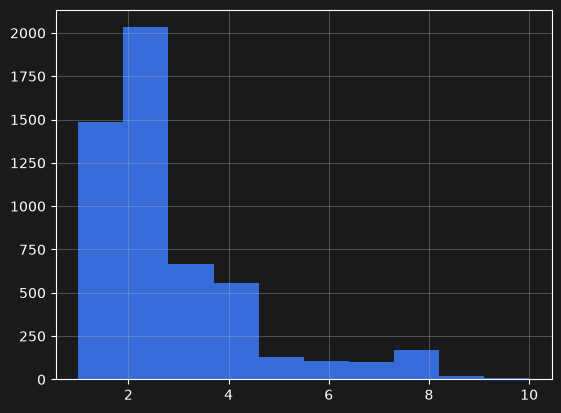

In [9]:
user_features["trip_session_ratio"].hist()

<Axes: xlabel='trip_session_ratio', ylabel='ave_rev_per_day'>

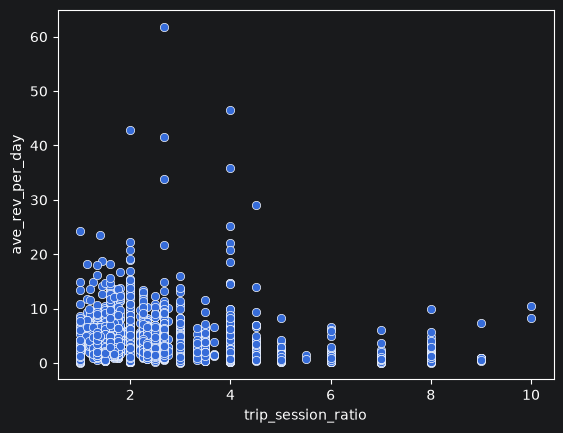

In [17]:
sns.scatterplot(user_features,x="trip_session_ratio", y="ave_rev_per_day")

<Axes: xlabel='Age', ylabel='ave_rev_per_day'>

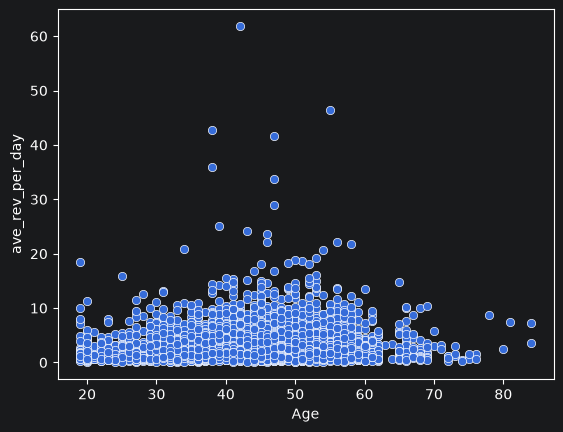

In [18]:
sns.scatterplot(user_features,x="Age", y="ave_rev_per_day")

<Axes: xlabel='Age', ylabel='count'>

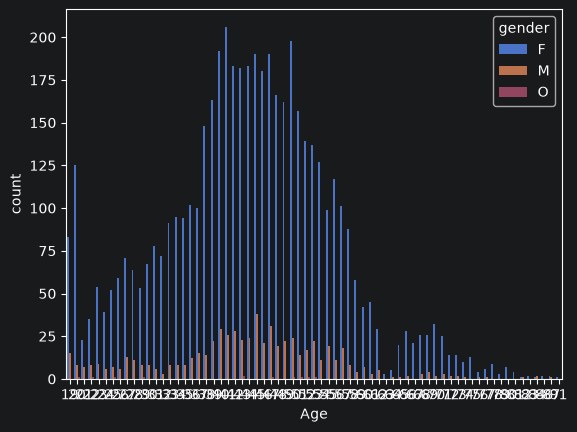

In [21]:
sns.countplot(user_features, x="Age", hue="gender")

<Axes: xlabel='has_children', ylabel='ave_rev_per_day'>

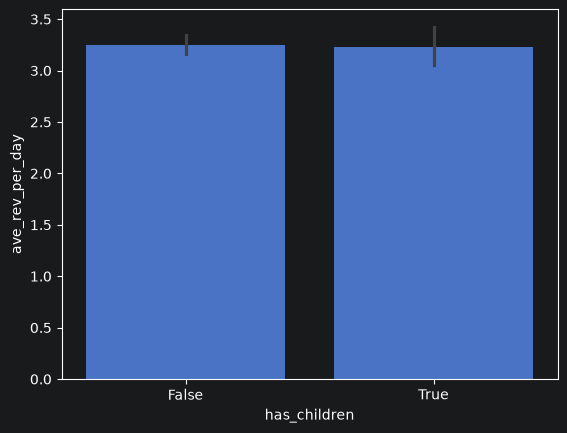

In [22]:
sns.barplot(user_features,x="has_children", y="ave_rev_per_day")

<Axes: ylabel='ave_rev_per_day'>

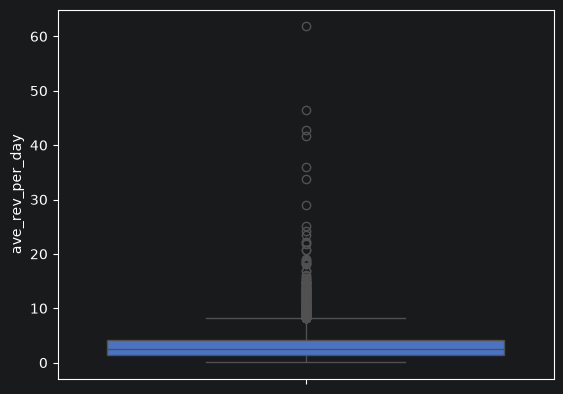

In [23]:
sns.boxplot(user_features, y="ave_rev_per_day")

<Axes: >

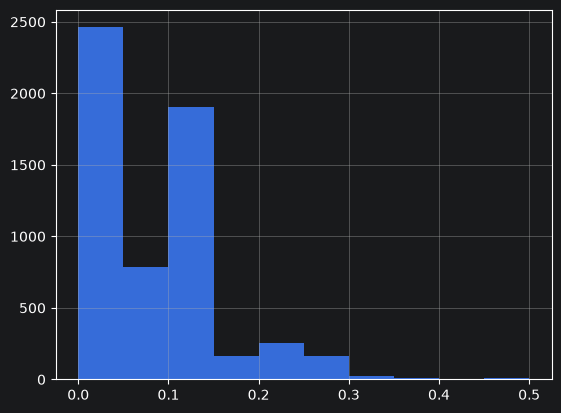

In [24]:
user_features['ave_discount'].hist()

array([[<Axes: title={'center': 'flight_no_bookings'}>,
        <Axes: title={'center': 'hotels_no_bookings'}>]], dtype=object)

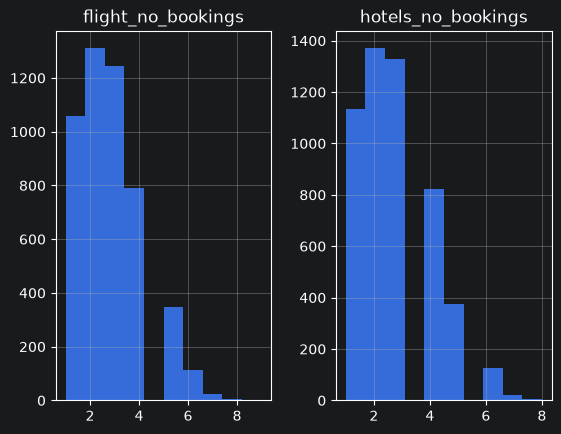

In [26]:
user_features[['flight_no_bookings','hotels_no_bookings']].hist()

<Axes: xlabel='ave_discount', ylabel='ave_rev_per_day'>

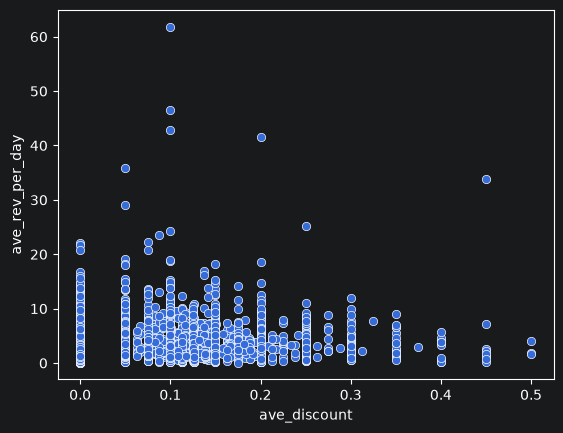

In [27]:
sns.scatterplot(user_features,x="ave_discount", y="ave_rev_per_day")

<Axes: ylabel='ave_discount'>

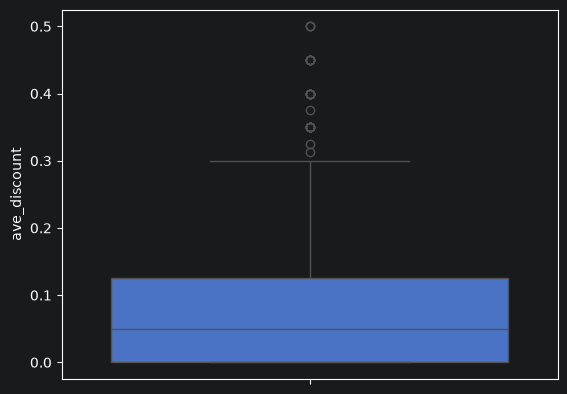

In [33]:
sns.boxplot(user_features, y="ave_discount")

<Axes: ylabel='hotel_avg_cost_per_r_n'>

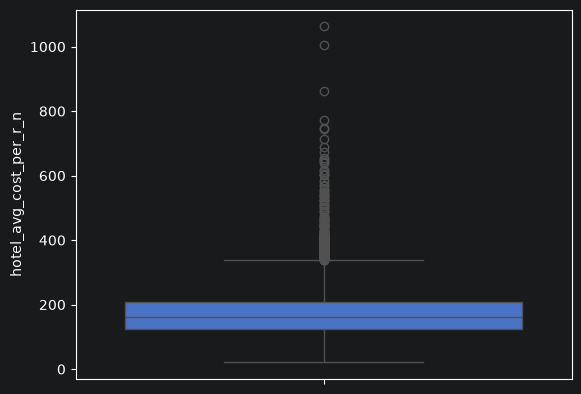

In [35]:
sns.boxplot(user_features, y="hotel_avg_cost_per_r_n")

<Axes: ylabel='flight_avg_cost_per_seat'>

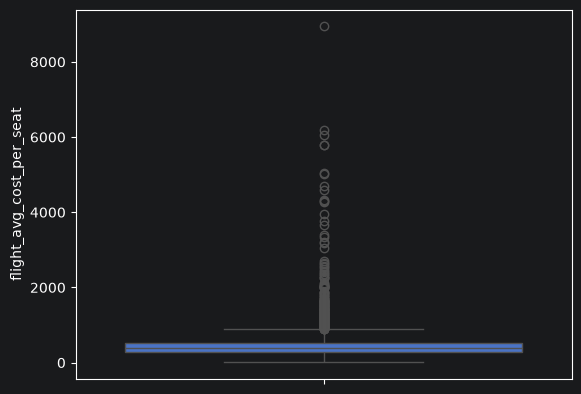

In [36]:
sns.boxplot(user_features, y="flight_avg_cost_per_seat")

In [9]:
user_features.to_csv('user_features_data/user_features_cleaned.csv', index=False)